<a href="https://colab.research.google.com/github/beomm2/AI_lab_seongbeom/blob/main/week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from google.colab import drive
drive.mount('/content/drive')

cudnn.benchmark = True
plt.ion()   # interactive mode

Mounted at /content/drive


In [2]:

# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/Colab Notebooks/2025-2-AI/sample_computer_vision'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


Using cuda device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


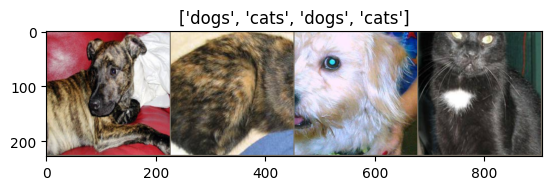

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [5]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [6]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


In [7]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5876 Acc: 0.7575
val Loss: 0.2094 Acc: 0.8950

Epoch 1/24
----------
train Loss: 0.5643 Acc: 0.7764
val Loss: 0.1944 Acc: 0.9350

Epoch 2/24
----------
train Loss: 0.5325 Acc: 0.7794
val Loss: 0.1698 Acc: 0.9450

Epoch 3/24
----------
train Loss: 0.4878 Acc: 0.7934
val Loss: 0.1807 Acc: 0.9400

Epoch 4/24
----------
train Loss: 0.4480 Acc: 0.8303
val Loss: 0.1280 Acc: 0.9800

Epoch 5/24
----------
train Loss: 0.4436 Acc: 0.8134
val Loss: 0.1494 Acc: 0.9700

Epoch 6/24
----------
train Loss: 0.4243 Acc: 0.8263
val Loss: 0.2578 Acc: 0.9450

Epoch 7/24
----------
train Loss: 0.3390 Acc: 0.8683
val Loss: 0.1964 Acc: 0.9600

Epoch 8/24
----------
train Loss: 0.2968 Acc: 0.8713
val Loss: 0.1436 Acc: 0.9750

Epoch 9/24
----------
train Loss: 0.2661 Acc: 0.8832
val Loss: 0.1681 Acc: 0.9750

Epoch 10/24
----------
train Loss: 0.2886 Acc: 0.8703
val Loss: 0.1425 Acc: 0.9650

Epoch 11/24
----------
train Loss: 0.2655 Acc: 0.8822
val Loss: 0.1489 Acc: 0.9650

Ep

In [8]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [9]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6297 Acc: 0.7226
val Loss: 0.1304 Acc: 0.9500

Epoch 1/24
----------
train Loss: 0.5383 Acc: 0.7954
val Loss: 0.1275 Acc: 0.9750

Epoch 2/24
----------
train Loss: 0.4676 Acc: 0.8253
val Loss: 0.1615 Acc: 0.9500

Epoch 3/24
----------
train Loss: 0.5310 Acc: 0.7844
val Loss: 0.1181 Acc: 0.9650

Epoch 4/24
----------
train Loss: 0.4188 Acc: 0.8293
val Loss: 0.1848 Acc: 0.9400

Epoch 5/24
----------
train Loss: 0.3983 Acc: 0.8363
val Loss: 0.1769 Acc: 0.9450

Epoch 6/24
----------
train Loss: 0.5199 Acc: 0.7954
val Loss: 0.1366 Acc: 0.9750

Epoch 7/24
----------
train Loss: 0.3547 Acc: 0.8523
val Loss: 0.1260 Acc: 0.9650

Epoch 8/24
----------
train Loss: 0.3767 Acc: 0.8244
val Loss: 0.1297 Acc: 0.9800

Epoch 9/24
----------
train Loss: 0.2935 Acc: 0.8693
val Loss: 0.1227 Acc: 0.9700

Epoch 10/24
----------
train Loss: 0.3725 Acc: 0.8363
val Loss: 0.1493 Acc: 0.9500

Epoch 11/24
----------
train Loss: 0.3486 Acc: 0.8493
val Loss: 0.1248 Acc: 0.9750

Ep

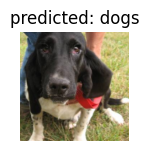

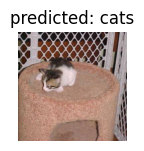

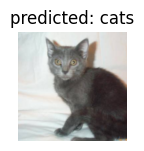

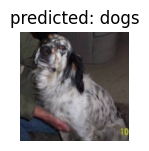

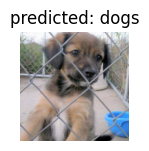

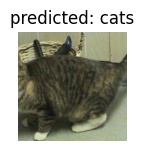

In [10]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [11]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

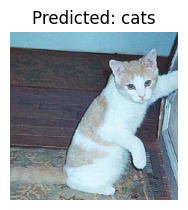

In [13]:
visualize_model_predictions(
    model_conv,
    img_path='/content/drive/MyDrive/Colab Notebooks/2025-2-AI/sample_computer_vision/val/cats/cat.4001.jpg'
)

plt.ioff()
plt.show()